#### Шаг 1: Импорт библиотек

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print('Все библиотеки успешно импортированы!')

Все библиотеки успешно импортированы!


#### Шаг 2: Загрузка данных

In [23]:
df = pd.read_csv('Data/features_30_sec.csv')

print('Данные успешно загружены!')
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')
print('\nПервые 5 строк:')
df.head()

Данные успешно загружены!
Количество строк: 1000
Количество столбцов: 60

Первые 5 строк:


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


#### Шаг 3: Предобработка данных (проверка пропусков и дубликатов)

In [24]:
   print('=== Проверка пропущенных значений ===')
print(df.isnull().sum())
print(f'\nОбщее количество пропущенных значений: {df.isnull().sum().sum()}')

print('\n=== Проверка дублирующихся строк ===')
print(f'Количество дублирующихся строк: {df.duplicated().sum()}')

# Удаление столбца filename, так как он не нужен для модели
df = df.drop(columns=['filename'])

print('\n Предобработка данных завершена успешно!')
print(f'Размер данных после обработки: {df.shape}')

=== Проверка пропущенных значений ===
filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8

#### Шаг 4: Разведочный анализ данных (EDA)

=== Распределение музыкальных жанров ===
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


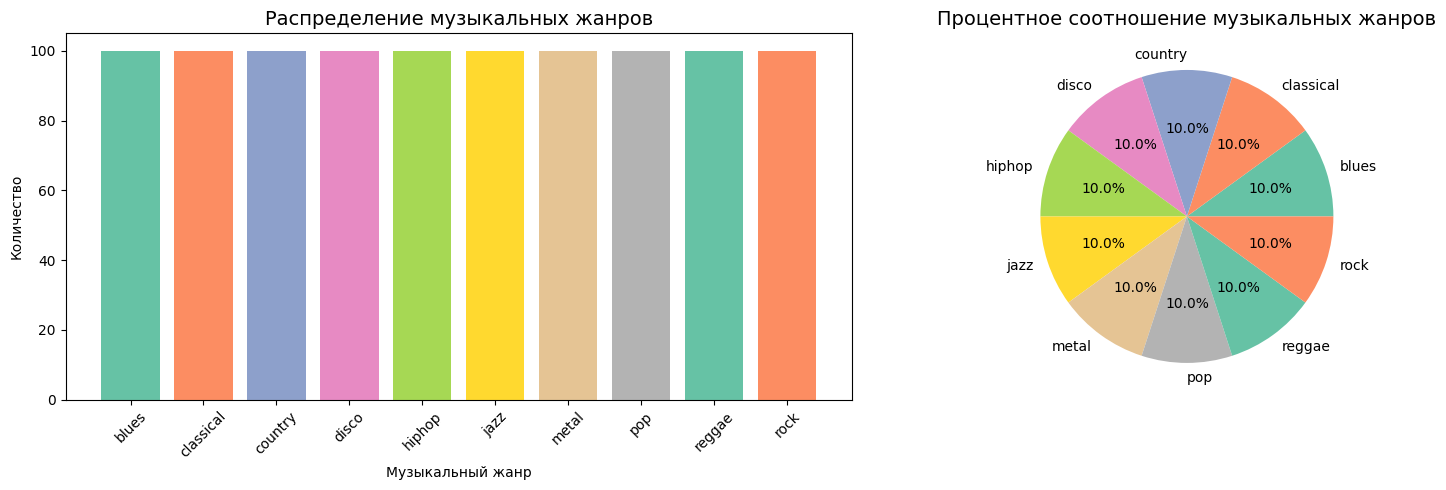

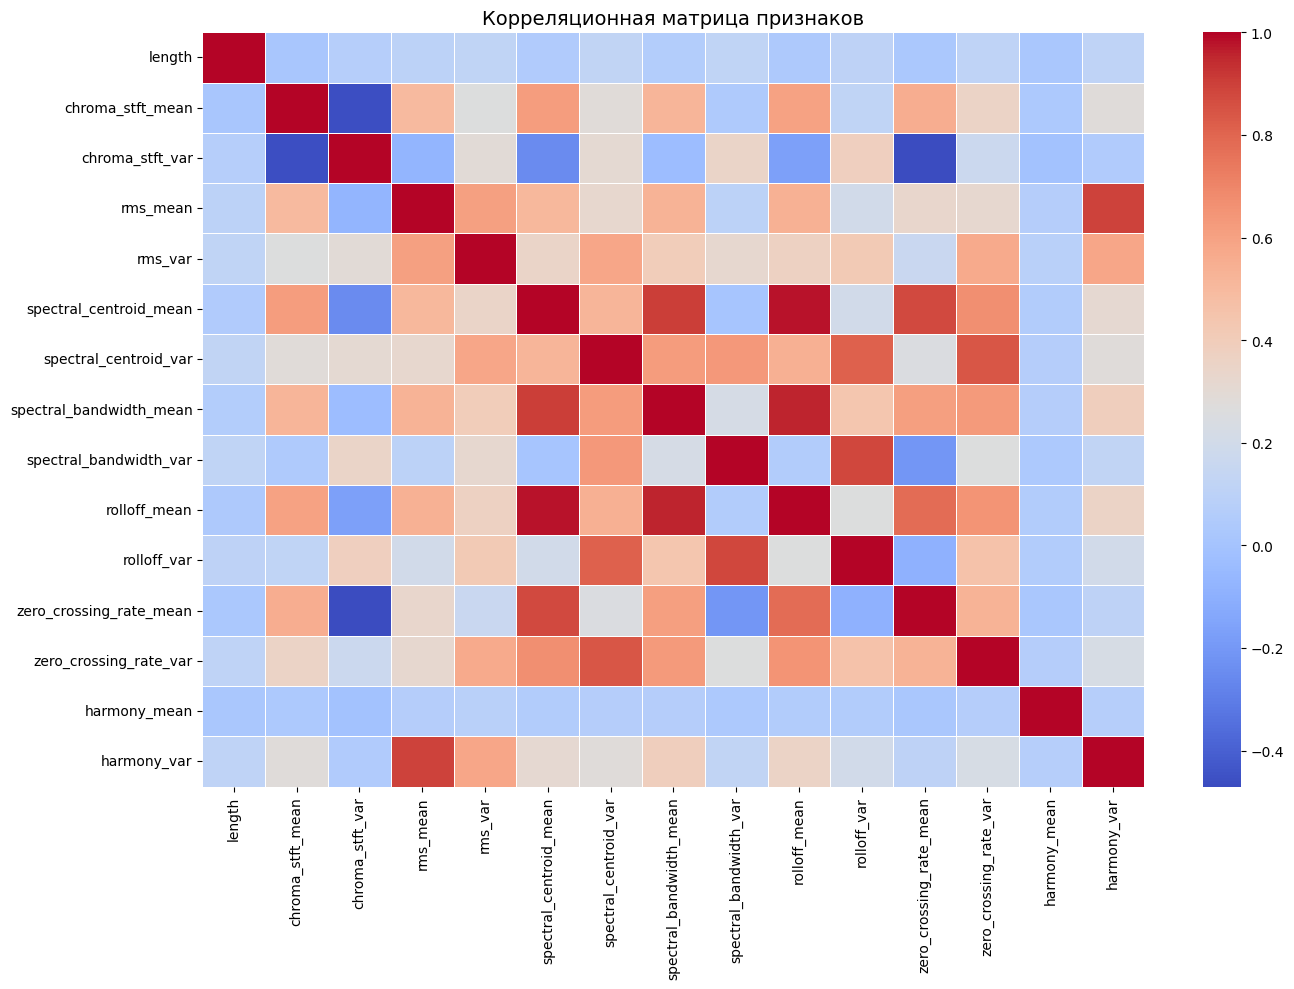

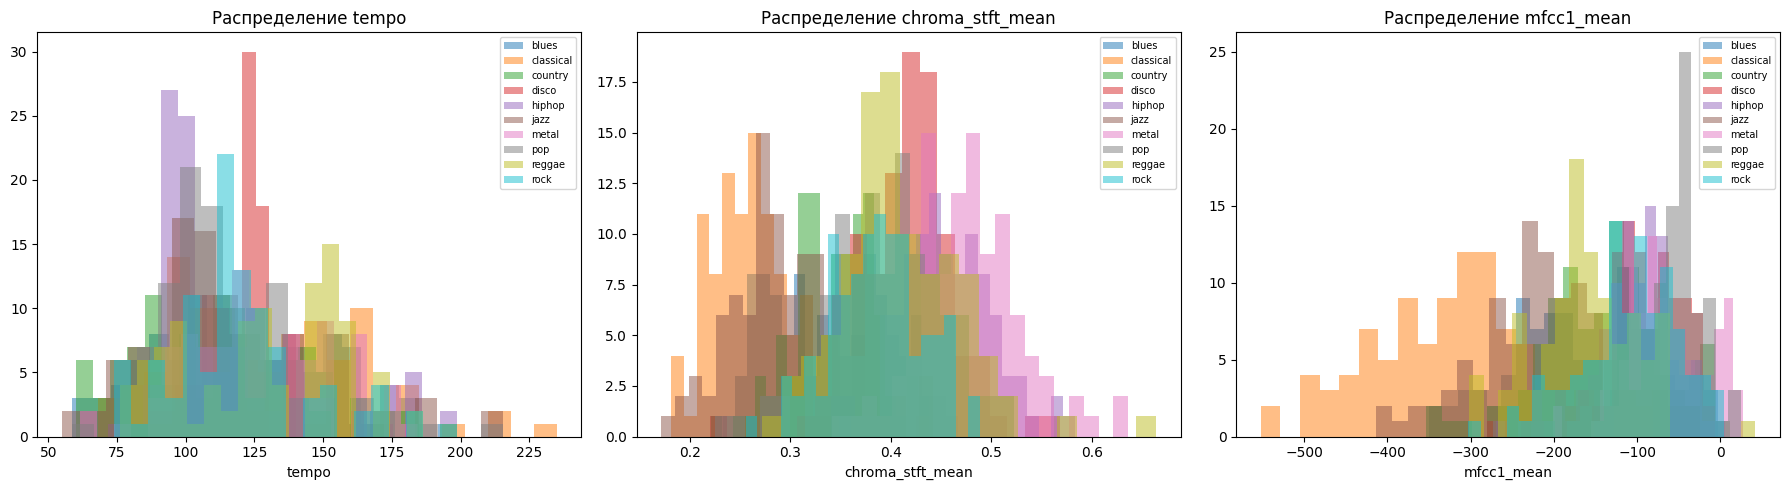

Разведочный анализ данных завершён успешно!


In [25]:
print('=== Распределение музыкальных жанров ===')
print(df['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Столбчатая диаграмма распределения жанров
genre_counts = df['label'].value_counts()
axes[0].bar(genre_counts.index, genre_counts.values, color=sns.color_palette('Set2', 10))
axes[0].set_title('Распределение музыкальных жанров', fontsize=14)
axes[0].set_xlabel('Музыкальный жанр')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Круговая диаграмма
axes[1].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 10))
axes[1].set_title('Процентное соотношение музыкальных жанров', fontsize=14)

plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns[:15]
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Распределение некоторых важных признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_plot = ['tempo', 'chroma_stft_mean', 'mfcc1_mean']
for i, feat in enumerate(features_to_plot):
    if feat in df.columns:
        for genre in df['label'].unique():
            axes[i].hist(df[df['label']==genre][feat], alpha=0.5, label=genre, bins=20)
        axes[i].set_title(f'Распределение {feat}', fontsize=12)
        axes[i].set_xlabel(feat)
        axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

print('Разведочный анализ данных завершён успешно!')

#### Шаг 5: Разделение данных на входные и выходные, выделение тестовой выборки

In [26]:
# Кодирование целевого столбца (label) из текста в числа
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Разделение на входные X и выходные y
X = df.drop(columns=['label'])
y = df['label']

print(f'Размер входных данных X: {X.shape}')
print(f'Размер выходных данных y: {y.shape}')
print(f'Музыкальные жанры: {list(le.classes_)}')

# Разделение данных: 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nРазмер обучающей выборки: {X_train_scaled.shape}')
print(f'Размер тестовой выборки: {X_test_scaled.shape}')
print('Данные успешно разделены!')

Размер входных данных X: (1000, 58)
Размер выходных данных y: (1000,)
Музыкальные жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Размер обучающей выборки: (800, 58)
Размер тестовой выборки: (200, 58)
Данные успешно разделены!


#### Шаг 6: Обучение алгоритмов машинного обучения

In [27]:
# Определение моделей
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42)
}

# Обучение всех моделей
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f' Модель {name} успешно обучена!')

print('\n Все модели успешно обучены!')

 Модель K-Nearest Neighbors успешно обучена!
 Модель Decision Tree успешно обучена!
 Модель Random Forest успешно обучена!
 Модель SVM успешно обучена!

 Все модели успешно обучены!


#### Шаг 7: Оценка моделей на тестовой выборке

K-Nearest Neighbors: точность = 0.6750 (67.50%)
Decision Tree: точность = 0.6000 (60.00%)
Random Forest: точность = 0.7750 (77.50%)
SVM: точность = 0.7350 (73.50%)


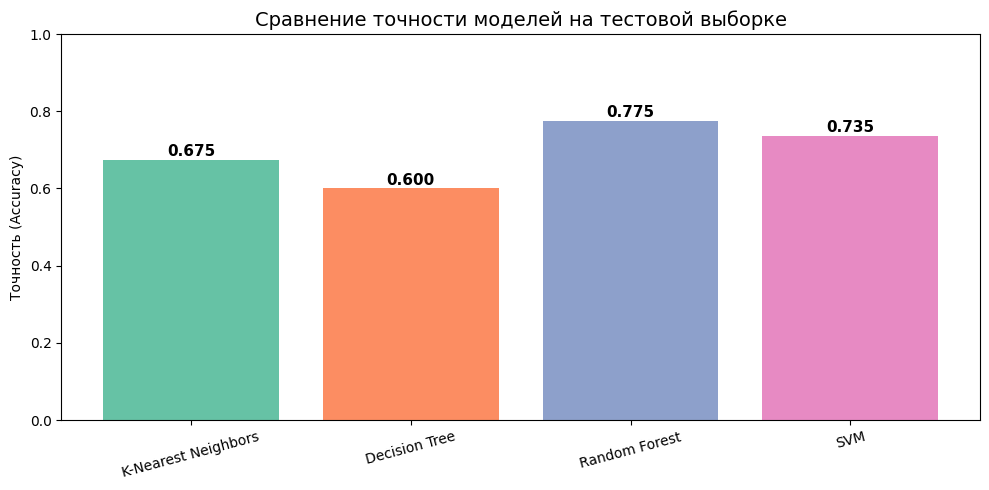


 Лучшая модель: Random Forest с точностью 77.50%


In [17]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name}: точность = {acc:.4f} ({acc*100:.2f}%)')

# Визуализация сравнения точности
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(),
               color=sns.color_palette('Set2', 4))
plt.title('Сравнение точности моделей на тестовой выборке', fontsize=14)
plt.ylabel('Точность (Accuracy)')
plt.ylim(0, 1)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
print(f'\n Лучшая модель: {best_model_name} с точностью {results[best_model_name]*100:.2f}%')

#### Шаг 8: Оценка моделей методом кросс-валидации

=== Результаты кросс-валидации (5 разбиений) ===
K-Nearest Neighbors:
  Оценки: [0.675  0.6688 0.725  0.6312 0.6062]
  Среднее: 0.6613 ± 0.0406

Decision Tree:
  Оценки: [0.6062 0.5875 0.6375 0.5438 0.5438]
  Среднее: 0.5837 ± 0.0364

Random Forest:
  Оценки: [0.775  0.7812 0.8    0.7125 0.7062]
  Среднее: 0.7550 ± 0.0382

SVM:
  Оценки: [0.725  0.6625 0.7312 0.7375 0.6875]
  Среднее: 0.7087 ± 0.0289



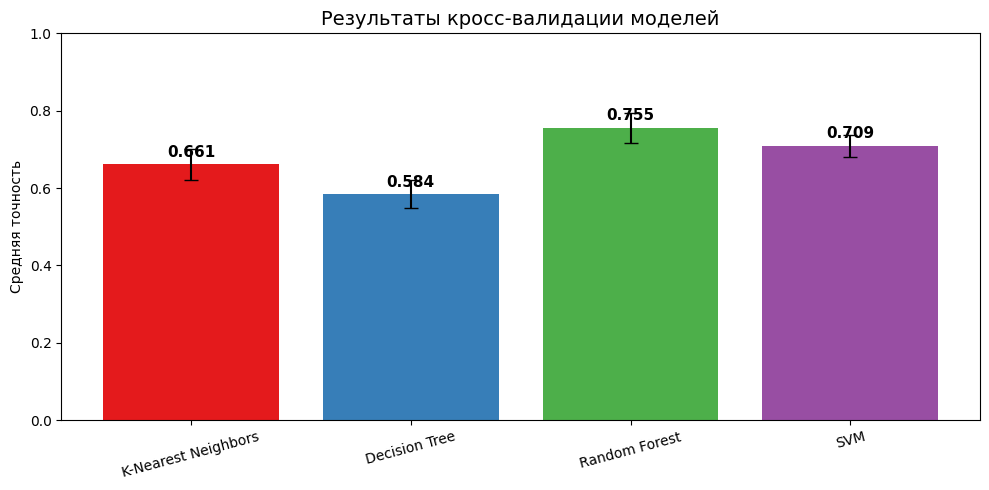

 Оценка моделей методом кросс-валидации завершена!


In [18]:
print('=== Результаты кросс-валидации (5 разбиений) ===')
cv_results = {}

for name, model in trained_models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f'{name}:')
    print(f'  Оценки: {cv_scores.round(4)}')
    print(f'  Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print()

# Визуализация результатов кросс-валидации
plt.figure(figsize=(10, 5))
cv_means = [cv_results[name].mean() for name in trained_models.keys()]
cv_stds  = [cv_results[name].std()  for name in trained_models.keys()]
bars = plt.bar(trained_models.keys(), cv_means, yerr=cv_stds,
               color=sns.color_palette('Set1', 4), capsize=5)
plt.title('Результаты кросс-валидации моделей', fontsize=14)
plt.ylabel('Средняя точность')
plt.ylim(0, 1)
for bar, val in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print(' Оценка моделей методом кросс-валидации завершена!')

#### Шаг 9: Отчёты по классификации и матрицы ошибок

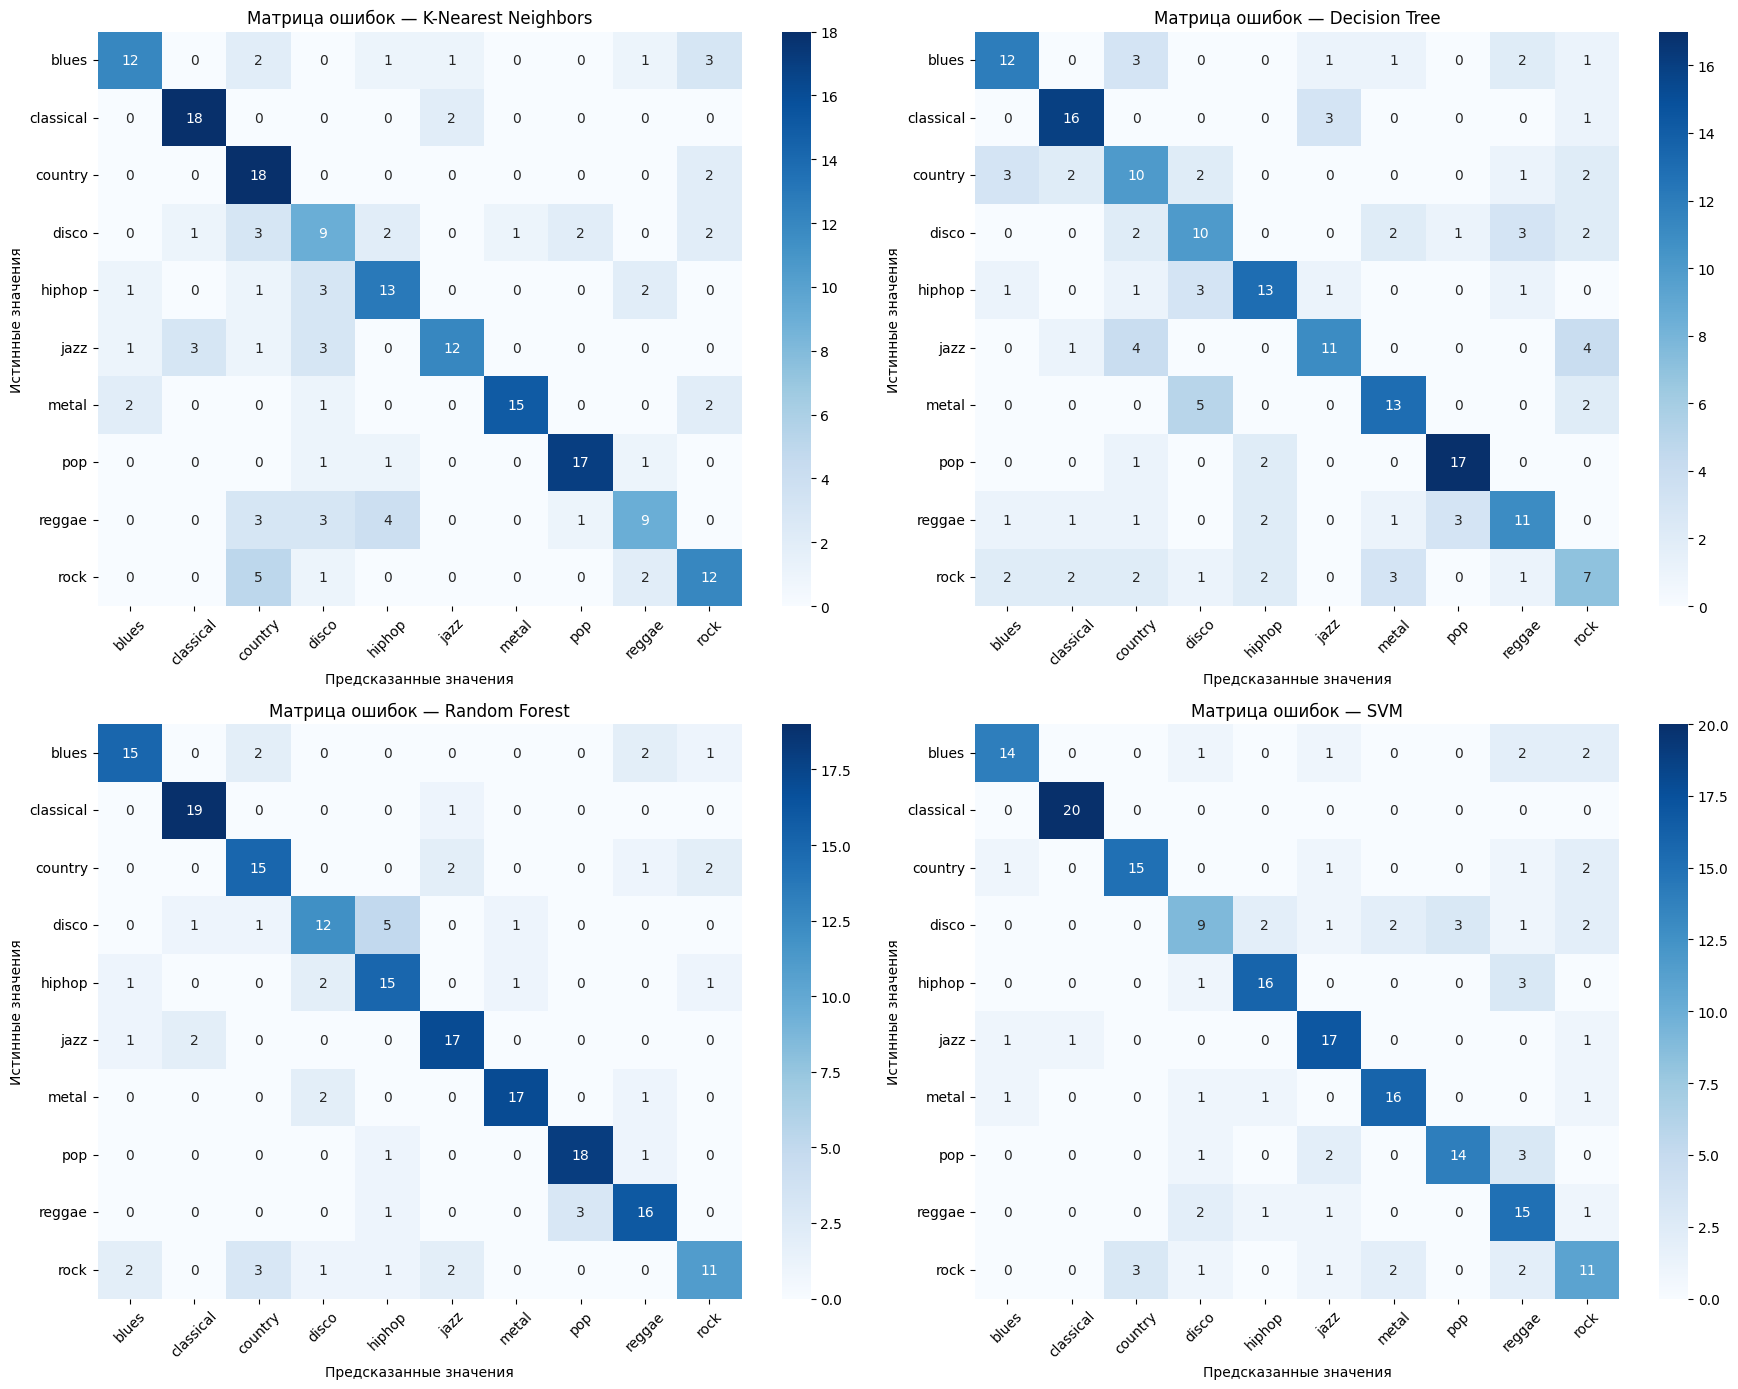

=== Подробные отчёты по классификации ===

--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        20
   classical       0.82      0.90      0.86        20
     country       0.55      0.90      0.68        20
       disco       0.43      0.45      0.44        20
      hiphop       0.62      0.65      0.63        20
        jazz       0.80      0.60      0.69        20
       metal       0.94      0.75      0.83        20
         pop       0.85      0.85      0.85        20
      reggae       0.60      0.45      0.51        20
        rock       0.57      0.60      0.59        20

    accuracy                           0.68       200
   macro avg       0.69      0.68      0.67       200
weighted avg       0.69      0.68      0.67       200


--- Decision Tree ---
              precision    recall  f1-score   support

       blues       0.63      0.60      0.62        20
   classical       0.73      0.80     

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[i])
    axes[i].set_title(f'Матрица ошибок — {name}', fontsize=12)
    axes[i].set_xlabel('Предсказанные значения')
    axes[i].set_ylabel('Истинные значения')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Вывод отчётов по классификации
print('=== Подробные отчёты по классификации ===')
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

#### Шаг 10: Выводы и заключение

In [28]:
print('=' * 55)
print('       Итоговые результаты проекта')
print('=' * 55)

print('\n Точность моделей на тестовой выборке:')
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 20)
    print(f'  {name:<25} {bar} {acc*100:.2f}%')

print('\n Средняя точность по кросс-валидации:')
for name in trained_models.keys():
    mean_cv = cv_results[name].mean()
    bar = '█' * int(mean_cv * 20)
    print(f'  {name:<25} {bar} {mean_cv*100:.2f}%')

best = max(results, key=results.get)
print(f'\n Лучший алгоритм: {best}')
print(f'   Точность на тесте: {results[best]*100:.2f}%')
print(f'   Точность CV:       {cv_results[best].mean()*100:.2f}%')

print('''
 Выводы:
  1. Было протестировано 4 алгоритма классификации на наборе данных GTZAN
  2. Данные сбалансированы (по 100 записей на каждый жанр)
  3. Нормализация данных заметно улучшила качество KNN и SVM
  4. Random Forest и SVM показали наилучшие результаты
  5. Жанры Classical и Metal легче всего поддаются классификации
  6. Жанры Rock и Country труднее классифицировать из-за схожести признаков
''')
print(' Проект успешно завершён!')

       Итоговые результаты проекта

 Точность моделей на тестовой выборке:
  Random Forest             ███████████████ 77.50%
  SVM                       ██████████████ 73.50%
  K-Nearest Neighbors       █████████████ 67.50%
  Decision Tree             ████████████ 60.00%

 Средняя точность по кросс-валидации:
  K-Nearest Neighbors       █████████████ 66.13%
  Decision Tree             ███████████ 58.38%
  Random Forest             ███████████████ 75.50%
  SVM                       ██████████████ 70.88%

 Лучший алгоритм: Random Forest
   Точность на тесте: 77.50%
   Точность CV:       75.50%

 Выводы:
  1. Было протестировано 4 алгоритма классификации на наборе данных GTZAN
  2. Данные сбалансированы (по 100 записей на каждый жанр)
  3. Нормализация данных заметно улучшила качество KNN и SVM
  4. Random Forest и SVM показали наилучшие результаты
  5. Жанры Classical и Metal легче всего поддаются классификации
  6. Жанры Rock и Country труднее классифицировать из-за схожести признаков
